# Definitions

In [1]:
from IPython import get_ipython
get_ipython().run_line_magic('reset', '-sf')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
#%matplotlib notebook
# Turn off interactive mode
plt.ioff()
plt.rcParams['interactive'] = False

#sns.set()
sns.set_style("ticks")
#sns.set_style({"xtick.direction": "in","ytick.direction": "in"})
#sns.set(rc={"xtick.bottom" : True, "ytick.left" : True})

#plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=30)  # fontsize of the axes title
plt.rc('axes', labelsize=30)  # fontsize of the x and y labels
plt.rc('xtick', labelsize=30)  # fontsize of the tick labels
plt.rc('ytick', labelsize=30)  # fontsize of the tick labels
plt.rc('legend', fontsize=30)  # legend fontsize
#plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title
# plt.rc('font', **{'family': 'serif', 'serif': ['Times New Roman']})
plt.rc('font', family='serif')

# plt.rc('text', usetex=True)
plt.rc('text', usetex=False)

plt.rc('xtick', direction='in') #xticks are plotted inside the figure
plt.rc('ytick', direction='in') #yticks are plotted inside the figure
plt.rcParams['xtick.major.pad'] = 10 #distance between ticks and numbers
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True

# set tick width and border width
plt.rcParams['xtick.major.size'] = 7
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['xtick.minor.size'] = 5
plt.rcParams['xtick.minor.width'] = 1

plt.rcParams['ytick.major.size'] = 7
plt.rcParams['ytick.major.width'] = 2
plt.rcParams['ytick.minor.size'] = 5
plt.rcParams['ytick.minor.width'] = 1

plt.rcParams['axes.linewidth'] = 2



In [2]:
# Different definitions for moving means

def moving_average(a, n=3):
    ret = np.cumsum(a, dtype=float)
    ret[n:] = ret[n:] - ret[:-n]
    return ret[n - 1:] / n

def moving_average_convolve(x, n=3):
    return np.convolve(x, np.ones(n), 'valid') / n

def moving_average_variable(x, n=3):
    # Initialize the result array with the same length as input array
    result = np.zeros(len(x))

    # Calculate the moving average for the edges with smaller window sizes
    for i in range(1, n):
        result[i-1] = np.mean(x[:i])
    
    # Calculate the moving average for the rest of the array with the full window size
    result[n-1:] = np.convolve(x, np.ones(n), 'valid') / n

    return result

def moving_average_variable_with_error(x, x_err, n=3):
    # Initialize the result arrays
    result = np.zeros(len(x))
    result_err = np.zeros(len(x))

    # Calculate the moving average and its error for the edges with smaller window sizes
    for i in range(1, n):
        result[i-1] = np.mean(x[:i])
        result_err[i-1] = np.sqrt(np.sum(x_err[:i]**2)) / i

    # Calculate the moving average and its error for the rest of the array with the full window size
    for i in range(n, len(x) + 1):
        result[i-1] = np.mean(x[i-n:i])
        result_err[i-1] = np.sqrt(np.sum(x_err[i-n:i]**2)) / n

    return result, result_err

def moving_average_variable_with_spread(x, n=3):
    # Initialize the result arrays
    result = np.zeros(len(x))
    result_std = np.zeros(len(x))

    # Calculate the moving average and its error for the edges with smaller window sizes
    for i in range(1, n):
        result[i-1] = np.mean(x[:i])
        result_std[i-1] = np.std(x[:i])

    # Calculate the moving average and its error for the rest of the array with the full window size
    for i in range(n, len(x) + 1):
        result[i-1] = np.mean(x[i-n:i])
        result_std[i-1] = np.std(x[i-n:i])

    return result, result_std

# Exit time statistics

## Histogram of exit times

### Ran droplet

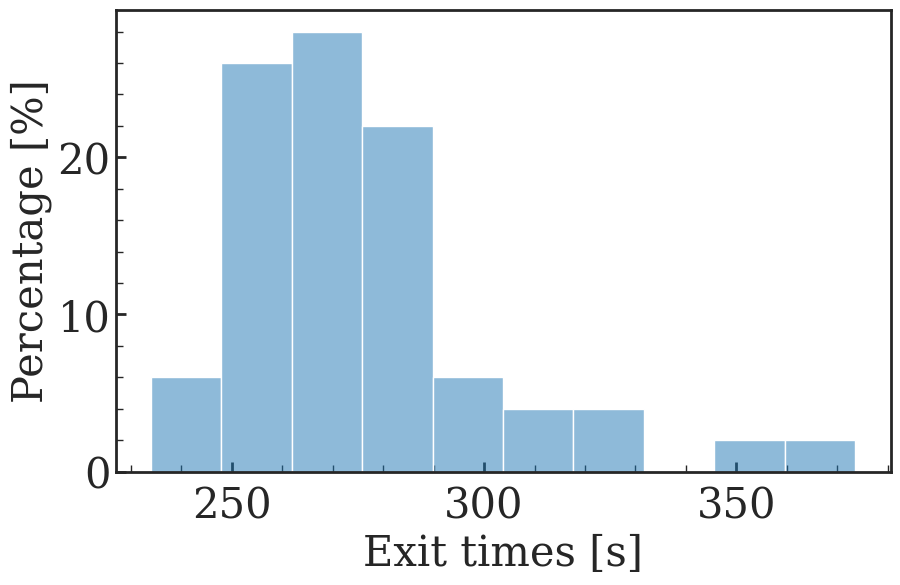

In [ ]:
# Plot the histogram of exit times

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

fig = plt.figure(figsize=(10, 6))

# Fix the scales for conc, time and position (adjust the units in plot titles accordingly)
t_unit = 10 # s # use seconds here as in 
r_unit = 0.4 # cm
beta_scale = 1e+04

# Load exit times for Chemoattraction

data = "/home/ecasual/Documents/Uni/droplet-maze/simulation-code/data"
data = "/home/ecasual/Documents/Uni/droplet-maze/simulation-code/output/1_particles"
#data = "/home/ecasual/Documents/Uni/droplet-maze/simulation-code/output/1_particles"
#data = "/home/ecasual/Documents/Uni/droplet-maze/simulation-code/output/2_particles"
#data = "/home/ecasual/Documents/Uni/droplet-maze/simulation-code/output/4_particles"
# data = "/home/ecasual/Documents/Uni/droplet-maze/simulation-code/output/10_particles"
exit_times = np.loadtxt(data + '/exit_times.txt', delimiter=' ', skiprows=1, usecols=0)

# Create a seaborn histogram for Chemoattraction
sns.histplot(exit_times * t_unit, stat='percent', label='Chemoattraction', color='tab:blue', alpha=0.5, line_kws={'linewidth':'5'})

# Overlay KDE plot for Chemoattraction with customized linestyle and linewidth
#sns.kdeplot(exit_times * t_unit, color='tab:blue', linestyle='-', linewidth=5.0)

# Plot settings
plt.xlabel(r'Exit times [s]')
plt.ylabel(r'Percentage [%]')
#plt.legend()
plt.xlim(0, 500)
#plt.ylim(0, 15)

# Show plot
plt.show()

# fig.savefig('/home/mukhopadhyay/Projects/maze/paper_figures/individual_figures/' + 'Ran_droplet_hist_tte.png', dpi=300, bbox_inches='tight')
#fig.savefig('/home/ecasual/Documents/Uni/droplet-maze/presentations/journalclub/journalclub_2026-06-16' + 'Ran_droplet_1-particle_hist_tte.png', dpi=300, bbox_inches='tight')
#fig.savefig('/home/ecasual/Documents/Uni/droplet-maze/presentations/journalclub/journalclub_2026-06-16' + 'Ran_droplet_2-particle_hist_tte.png', dpi=300, bbox_inches='tight')
#fig.savefig('/home/ecasual/Documents/Uni/droplet-maze/presentations/journalclub/journalclub_2026-06-16' + 'Ran_droplet_4-particle_hist_tte.png', dpi=300, bbox_inches='tight')
# fig.savefig('/home/ecasual/Documents/Uni/droplet-maze/presentations/journalclub/journalclub_2026-06-16' + 'Ran_droplet_10-particle_hist_tte.png', dpi=300, bbox_inches='tight')

In [23]:
exited_mask = exit_times > 0
np.mean(exit_times[exited_mask] * t_unit), np.std(exit_times[exited_mask] * t_unit)/np.sqrt(len(exit_times[exited_mask]))


(np.float64(51.41436639118457), np.float64(0.3745111931680805))

In [24]:
np.mean(1/(exit_times[exited_mask] * t_unit)), np.std(1/(exit_times[exited_mask] * t_unit))/np.sqrt(len(exit_times[exited_mask]))


(np.float64(0.019787807636015908), np.float64(0.0001298525827488917))

### Strategy comparison

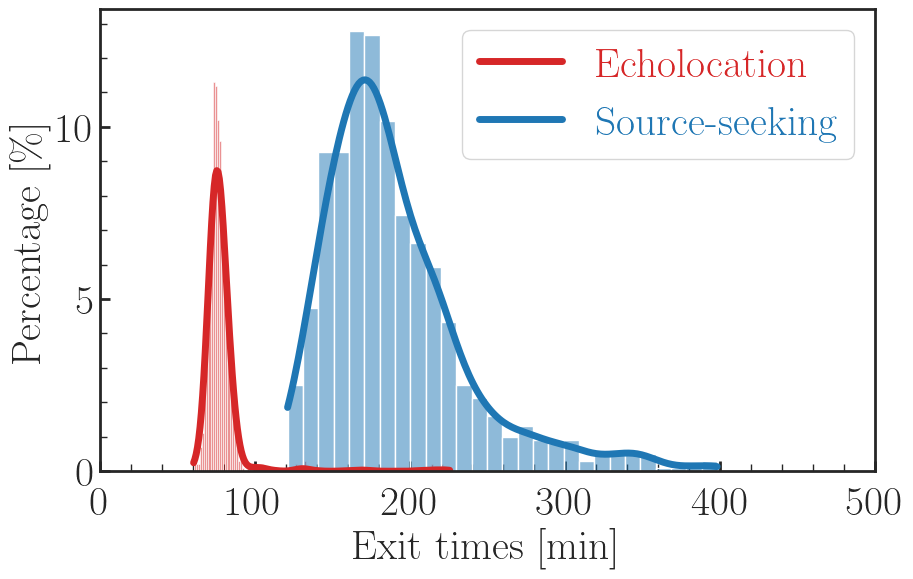

In [ ]:
# Plot the histogram of exit times

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

fig = plt.figure(figsize=(10, 6))

# Fix the scales for conc, time and position (adjust the units in plot titles accordingly)
t_unit = 1 # minutes
r_unit = 1e-01 # mm

# Load exit times for Chemorepulsion
data_CR = '/home/mukhopadhyay/Projects/maze/GNU_parallel_runs/strategy_comparison/data_CR'
exit_times_CR = np.loadtxt(data_CR + '/exit_times.txt', delimiter=' ', skiprows=1, usecols=0)

# Load exit times for Chemoattraction
data_CA = '/home/mukhopadhyay/Projects/maze/GNU_parallel_runs/strategy_comparison/data_CA'
exit_times_CA = np.loadtxt(data_CA + '/exit_times.txt', delimiter=' ', skiprows=1, usecols=0)

# Create a seaborn histogram for Chemorepulsion
sns.histplot(exit_times_CR * t_unit, stat='percent', kde=True, color='tab:red', alpha=0.5, line_kws={'linewidth':'5', 'label':'Echolocation'})

# Overlay KDE plot for Chemorepulsion with customized linestyle and linewidth
#sns.kdeplot(exit_times_CR * t_unit, color='tab:red', linestyle='-', linewidth=5.0)

# Create a seaborn histogram for Chemoattraction
sns.histplot(exit_times_CA * t_unit, stat='percent', kde=True, color='tab:blue', alpha=0.5, line_kws={'linewidth':'5', 'label':'Source-seeking'})

# Overlay KDE plot for Chemoattraction with customized linestyle and linewidth
#sns.kdeplot(exit_times_CA * t_unit, color='tab:blue', linestyle='-', linewidth=5.0)

# Plot settings
plt.xlabel(r'Exit times [min]')
plt.ylabel(r'Percentage [\%]')
plt.legend(labelcolor='linecolor')
plt.xlim(0, 500)

# Show plot
plt.show()

#fig.savefig('/home/mukhopadhyay/Projects/maze/paper_figures/individual_figures/' + 'hist_tte.png', dpi=300, bbox_inches='tight')

In [53]:
print(np.mean(exit_times_CA * t_unit), np.std(exit_times_CA * t_unit)/np.sqrt(len(exit_times_CA)))
print(np.mean(exit_times_CR * t_unit), np.std(exit_times_CR * t_unit)/np.sqrt(len(exit_times_CR)))

190.50664688128774 1.471940517684845
78.205372 0.44931026082609776


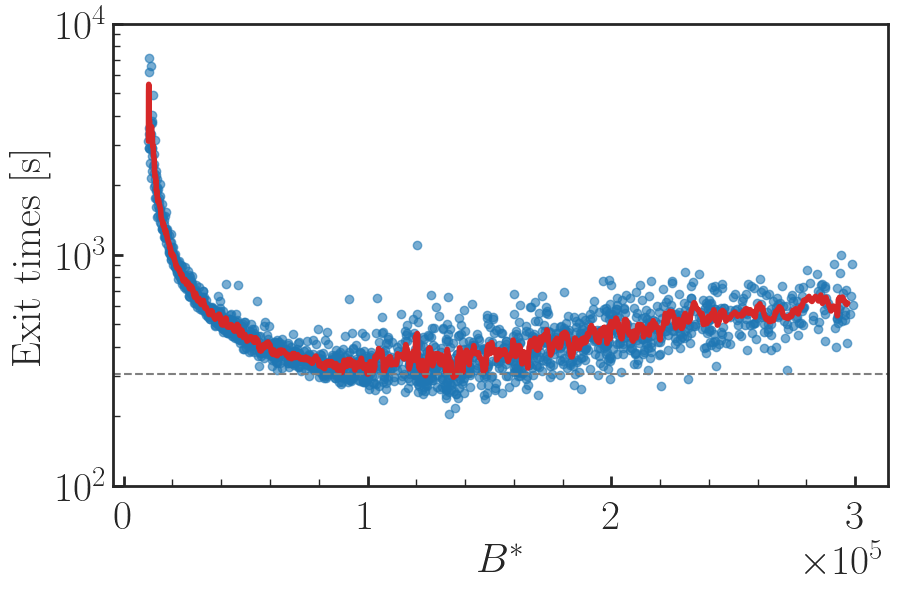

In [42]:
# Plot exit times vs beta

# Load data from the file
data = np.loadtxt('/home/mukhopadhyay/Projects/maze/GNU_parallel_runs/phase_diagram/data_beta_exit_times/exit_times_combined.txt', skiprows=1)

# Fix the scales for conc, time and position (adjust the units in plot titles accordingly)
t_unit = 10 # s
r_unit = 4 # mm
beta_scale = 1e+04

# Separate the columns
exit_times = data[:, 0] * t_unit
beta = np.abs(data[:, 1]) * beta_scale

# Filter out inf values
finite_indices = np.isfinite(exit_times) & np.isfinite(beta)
exit_times = exit_times[finite_indices]
beta = beta[finite_indices]

# Set up the plot
plt.figure(figsize=(10, 6))

# Scatter plot of exit_times vs beta
plt.plot(beta, exit_times, 'o', alpha=0.6)

et_av, et_err = moving_average_variable_with_spread(exit_times[np.argsort(beta)], n=10)
beta_av, beta_err = moving_average_variable_with_spread(beta[np.argsort(beta)], n=10)

plt.plot(beta_av, et_av, linewidth=4, color='C3')
#plt.fill_between(beta_av, et_av - et_err, et_av + et_err, alpha=0.2)

# Labeling the plot
#plt.title('Exit Times vs. Beta')
plt.xlabel(r'$B^*$')
plt.ylabel(r'Exit times [s]')
plt.axhline(306, linestyle='dashed', color='gray')
plt.yscale('log')
plt.ylim(1e2, 1e4)
plt.ticklabel_format(axis='x', style='sci', scilimits=(0,0))

# Show the legend
#plt.legend()

# Show the plot
plt.show()


## Exit time vs distance

In [56]:
# Calculate the mean time to exit as a function of distance from the exit point
# for all trajectory files

# Import necessary libraries
import os
import sys
import numpy as np
from queue import PriorityQueue
from tqdm import tqdm

sys.path.append(os.path.join(os.getcwd(), 'optimal_beta_Ran_droplet'))
from maze_functions import maze_from_file

# Data directory
data = 'optimal_beta_Ran_droplet/data/'  # for linux

# Load the maze
maze = maze_from_file('optimal_beta_Ran_droplet/different_mazes/Ran_maze_size_prop_to_droplet.tsv')
wall = np.transpose(np.where(maze == 0))

# Initialize a memorization dictionary
memo = {}

def get_distance(maze, start, end):
    # Check if the distance is already calculated
    if (start, end) in memo:
        return memo[(start, end)]
    
    # If not, calculate the distance and store it in the memo dictionary
    distance, _ = distance_to_exit(maze, start, end)
    memo[(start, end)] = distance
    
    return distance

def distance_to_exit(maze, start, end):
    def neighbors(node):
        i, j = node
        candidates = [(i+1, j), (i-1, j), (i, j+1), (i, j-1)]
        return [(ni, nj) for ni, nj in candidates if 0 <= ni < maze.shape[0] and 0 <= nj < maze.shape[1] and maze[ni, nj] == 1]

    pq = PriorityQueue()
    pq.put((0, start, 0, [start]))

    visited = set()

    while not pq.empty():
        cost, current, distance, path = pq.get()

        if current == end:
            return distance, path

        if current in visited:
            continue

        visited.add(current)

        for neighbor in neighbors(current):
            if neighbor not in visited:
                pq.put((cost + 1, neighbor, distance + 1, path + [neighbor]))

    return float('inf'), []

# Define the exit point
exit_point = np.array([73.0, 20.0])

# Define the radius of the circular exit zone
#exit_radius = 20.0

# Get list of all trajectory files
trajectory_files = [f for f in os.listdir(data) if f.startswith('full_traj_') and f.endswith('.txt')]

# Initialize lists to store results for plotting
all_distances = []
all_exit_times = []

for traj_file in tqdm(trajectory_files):
    # Load trajectory data
    full_traj = np.loadtxt(os.path.join(data, traj_file), skiprows=1)
    
    # Assuming column indices, update them based on your actual data
    time_col = 0
    x_col = 1
    y_col = 2
    
    # Get the exit point from the last row of the trajectory
    #exit_point = np.array([full_traj[-1, x_col], full_traj[-1, y_col]])
    
    # Calculate distance from the exit point using the pathfinding algorithm
    distances = [get_distance(maze, (int(px), int(py)), tuple(map(int, exit_point))) for px, py in zip(full_traj[:, x_col], full_traj[:, y_col])]
    
    # Find the time when particles enter the exit zone for the first time
    exit_times = full_traj[-1, time_col] - full_traj[:, time_col]
    
    # Store the results for plotting
    all_distances.extend(distances)
    all_exit_times.extend(exit_times)

# Convert lists to numpy arrays
all_distances = np.array(all_distances)
all_exit_times = np.array(all_exit_times)

# Get unique distances and mean exit times
unique_distances = np.unique(all_distances)
mean_exit_times = np.array([np.mean(all_exit_times[all_distances == d]) for d in unique_distances])
std_exit_times = np.array([np.std(all_exit_times[all_distances == d]) for d in unique_distances])

# save the data
np.savetxt(data + 'exit_times_from_different_points.txt', np.column_stack((unique_distances, mean_exit_times, std_exit_times)), header='Distance, Mean Exit Time, Standard Deviation', fmt='%.6f')


100%|██████████| 921/921 [01:34<00:00,  9.76it/s]


### Ran droplet

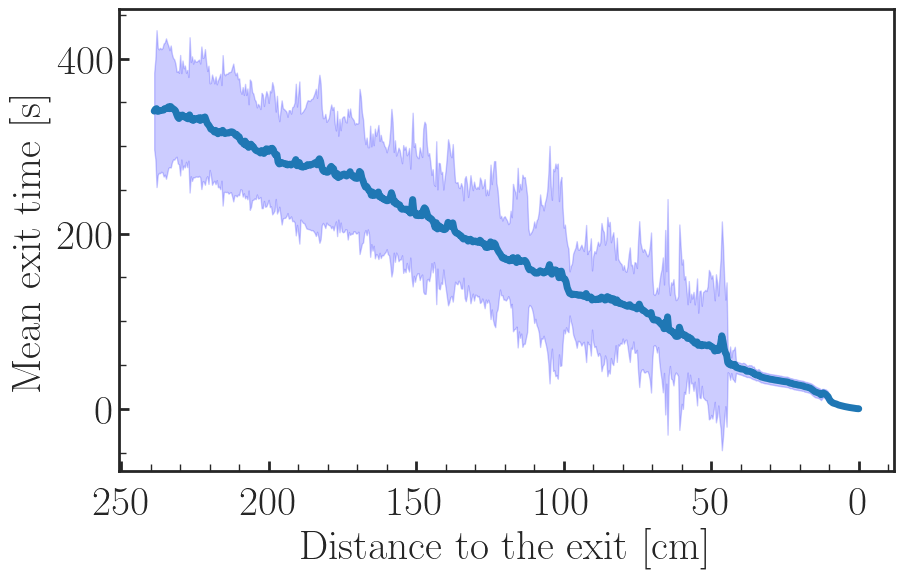

In [ ]:
# Load the data from the text file generated in previous cell and plot the results

import numpy as np
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 6))

# Fix the scales for conc, time and position (adjust the units in plot titles accordingly)
t_unit = 10 # s
r_unit = 0.4 # cm
beta_scale = 1e+04

# Load the data from the text file
data = 'optimal_beta_Ran_droplet/data/'
exit_data = np.loadtxt(data + 'exit_times_from_different_points.txt', delimiter=' ', skiprows=1)

# Extract columns
unique_distances = exit_data[:, 0] * r_unit
mean_exit_times = exit_data[:, 1] * t_unit
std_exit_times = exit_data[:, 2] * t_unit

# Plot mean time to exit as a function of unique distances with standard deviation
plt.plot(unique_distances, mean_exit_times, color='tab:blue', linewidth=5.0, label='mean')
plt.fill_between(unique_distances, mean_exit_times - std_exit_times, mean_exit_times + std_exit_times, color='b', alpha=0.2, label='standard deviation')


plt.xlabel(r'Distance to the exit [cm]')
plt.ylabel(r'Mean exit time [s]')
#plt.yscale('log')
#plt.xscale('log')
#plt.legend()

plt.gca().invert_xaxis()
plt.show()

#fig.savefig('/home/mukhopadhyay/Projects/maze/paper_figures/individual_figures/' + 'Ran_droplet_mean_tte_vs_dist.png', dpi=300, bbox_inches='tight')

### Strategy comparison

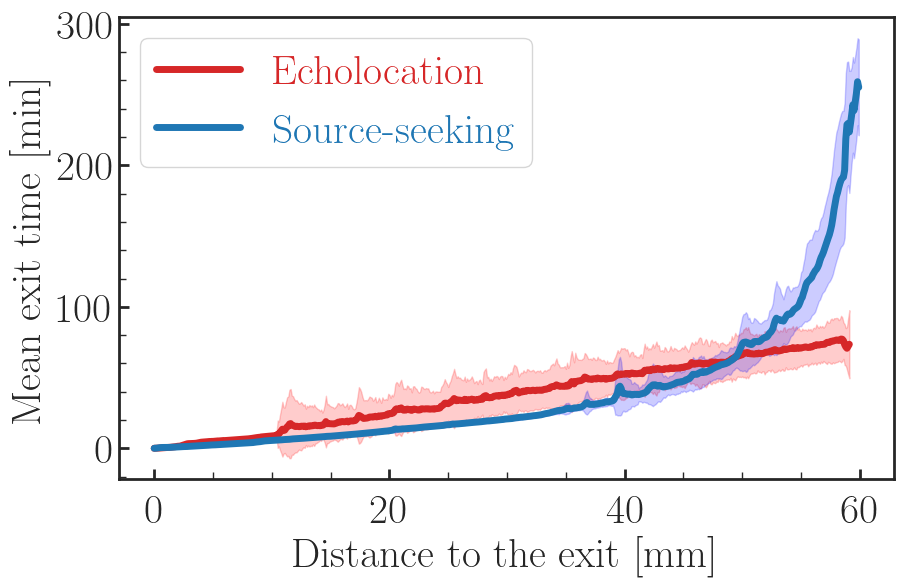

In [ ]:
# Load the data from the text file generated in previous cell and plot the results

import numpy as np
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 6))

# Fix the scales for conc, time and position (adjust the units in plot titles accordingly)
t_unit = 1 # minutes
r_unit = 1e-01 # mm

# Load the data from the text file
data = 'strategy_comparison/data_CR/'
exit_data = np.loadtxt(data + 'exit_times_from_different_points.txt', delimiter=' ', skiprows=1)

# Extract columns
unique_distances = exit_data[:, 0] * r_unit
mean_exit_times = exit_data[:, 1] * t_unit
std_exit_times = exit_data[:, 2] * t_unit

# Plot mean time to exit as a function of unique distances with standard deviation
plt.plot(unique_distances, mean_exit_times, color='tab:red', linewidth=5.0, label='Echolocation')
plt.fill_between(unique_distances, mean_exit_times - std_exit_times, mean_exit_times + std_exit_times, color='r', alpha=0.2)


# Load the data from the text file
data = 'strategy_comparison/data_CA/'
exit_data = np.loadtxt(data + 'exit_times_from_different_points.txt', delimiter=' ', skiprows=1)

# Extract columns
unique_distances = exit_data[:, 0] * r_unit
mean_exit_times = exit_data[:, 1] * t_unit
std_exit_times = exit_data[:, 2] * t_unit

# Plot mean time to exit as a function of unique distances with standard deviation
plt.plot(unique_distances, mean_exit_times, color='tab:blue', linewidth=5.0, label='Source-seeking')
plt.fill_between(unique_distances, mean_exit_times - std_exit_times, mean_exit_times + std_exit_times, color='b', alpha=0.2)


plt.xlabel(r'Distance to the exit [mm]')
plt.ylabel(r'Mean exit time [min]')
#plt.yscale('log')
#plt.xscale('log')
plt.legend(labelcolor='linecolor')

#plt.gca().invert_xaxis()
plt.show()

#fig.savefig('/home/mukhopadhyay/Projects/maze/paper_figures/individual_figures/' + 'mean_tte_vs_dist.png', dpi=300, bbox_inches='tight')

m = 4.340, b = -5.482
dm = 0.089, db = 0.151


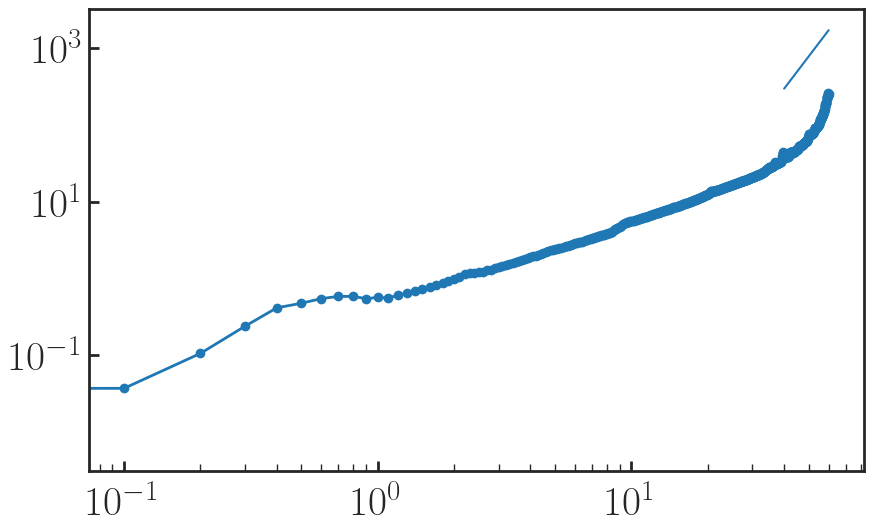

In [87]:
# Fit data
from scipy.optimize import curve_fit

def linear(x, m, b):
    return m*x + b

fit_from = 400
fit_upto = 600
popt, pcov = curve_fit(linear, np.log10(unique_distances[fit_from:fit_upto]), np.log10(mean_exit_times[fit_from:fit_upto])) #power law
#popt, pcov = curve_fit(linear, unique_distances[fit_from:fit_upto], np.log(mean_exit_times[fit_from:fit_upto])) #exponential
m, b = popt
dm, db = np.sqrt(np.diag(pcov))

print('m = %.3f, b = %.3f' % (m, b))
print('dm = %.3f, db = %.3f' % (dm, db))

fig,ax = plt.subplots(figsize=(10, 6))
ax.plot(unique_distances, mean_exit_times, 'o-', color='tab:blue', linewidth=2.0, label='Chemoattraction')
shift = 1.0

#power law
ax.plot(unique_distances[fit_from:fit_upto], np.power(10,linear(np.log10(unique_distances[fit_from:fit_upto]), m, b)+ shift), label=r'$\propto t^{%.2f}$' % (m))
#exponential
#ax.plot(unique_distances[fit_from:fit_upto], np.exp(linear(unique_distances[fit_from:fit_upto], m, b)+ shift), label=r'$\propto t^{%.2f}$' % (m))

#ax.semilogy()
ax.loglog()
plt.show()

# Success Fraction statistics

In [38]:
# Find the times spent in correct and wrong paths for all trajectories
%reload_ext autoreload
%autoreload 2


import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from queue import PriorityQueue
from scipy.spatial import KDTree
import seaborn as sns
from tqdm import tqdm

sys.path.append(os.path.join(os.getcwd(), 'strategy_comparison'))
from maze_functions import maze_from_file

data = '/home/mukhopadhyay/Projects/maze/GNU_parallel_runs/phase_diagram/data_beta_sf/20_30'  # for linux

# Get list of all trajectory files
trajectory_files = [f for f in os.listdir(data) if f.startswith('full_traj_') and f.endswith('.txt')]
jobid = [f[len('full_traj_'):-len('.txt')] for f in trajectory_files]

# Initialize an empty dictionary to store Beta values corresponding to JobIDs
jobid_to_beta = {}

# Read the exit_times.txt file and populate the dictionary
with open(data + '/exit_times.txt', 'r') as f:
    next(f)  # Skip the header line
    for line in f:
        exit_time, beta, job_id = line.split()
        jobid_to_beta[job_id] = float(beta)  # Store beta value as float

# Get the Beta values corresponding to each jobid
beta_values = [jobid_to_beta[jid] for jid in jobid]

# Convert the list of Beta values to a numpy array (optional)
beta_values_array = np.array(beta_values)


# Generate a maze
maze = maze_from_file('/home/mukhopadhyay/Projects/maze/GNU_parallel_runs/phase_diagram/different_mazes/Ran_maze_size_prop_to_droplet.tsv')
wall = np.transpose(np.where(maze == 0))

def distance_to_exit(maze, start, end):
    def neighbors(node):
        i, j = node
        candidates = [(i+1, j), (i-1, j), (i, j+1), (i, j-1)]
        return [(ni, nj) for ni, nj in candidates if 0 <= ni < maze.shape[0] and 0 <= nj < maze.shape[1] and maze[ni, nj] == 1]

    pq = PriorityQueue()
    pq.put((0, start, 0, [start]))

    visited = set()

    while not pq.empty():
        cost, current, distance, path = pq.get()

        if current == end:
            return distance, path

        if current in visited:
            continue

        visited.add(current)

        for neighbor in neighbors(current):
            if neighbor not in visited:
                pq.put((cost + 1, neighbor, distance + 1, path + [neighbor]))

    return float('inf'), []

# Define the start and end points
start_point = (2, 81)  # Ensure these points are within the maze bounds
end_point = (73, 20)    # Change this to your actual end point

# Ensure the start and end points are within the bounds of the maze
assert 0 <= start_point[0] < maze.shape[0] and 0 <= start_point[1] < maze.shape[1], "Start point is out of bounds"
assert 0 <= end_point[0] < maze.shape[0] and 0 <= end_point[1] < maze.shape[1], "End point is out of bounds"

# Calculate the shortest path from start to end
distance, path = distance_to_exit(maze, start_point, end_point)

# Create KDTree for the model trajectory
model_tree = KDTree(path)



# Initialize lists to store results for plotting
total_times_correct = []
total_times_wrong = []
exit_times = []

# Set tolerance for classification
tolerance = 4.0

for traj_file in tqdm(trajectory_files):
    # Load trajectory data
    full_traj = np.loadtxt(os.path.join(data, traj_file), skiprows=1)
    trajectory = full_traj[:, [1, 2]]
    times = full_traj[:, 0]

    correct_times = []
    wrong_times = []
    
    # Classify trajectory segments based on distance to model trajectory
    for i, point in enumerate(trajectory):
        distance, index = model_tree.query(point)
        time_spent = times[i + 1] - times[i] if i < len(times) - 1 else 0  # Time spent at this point
        if distance <= tolerance:
            correct_times.append(time_spent)
        else:
            wrong_times.append(time_spent)

    # Convert to numpy arrays for convenience
    correct_times = np.array(correct_times)
    wrong_times = np.array(wrong_times)

    # Calculate total time spent in correct and wrong paths
    total_time_correct = np.sum(correct_times)
    total_time_wrong = np.sum(wrong_times)

    total_times_correct.append(total_time_correct)
    total_times_wrong.append(total_time_wrong)
    exit_times.append(times[-1] - times[0])

# Convert lists to numpy arrays
total_times_correct = np.array(total_times_correct)
total_times_wrong = np.array(total_times_wrong)
exit_times = np.array(exit_times)

# save the data
#np.savetxt(data + '/success_fraction_time.txt', np.column_stack((total_times_correct, total_times_wrong, exit_times)), 
#           header='Time in RIGHT path, Time in Wrong path, Total exit time', fmt='%.4f')

np.savetxt(data + '/success_fraction.txt', 
           np.column_stack((total_times_correct, total_times_wrong, exit_times, beta_values_array)), 
           header='Time in RIGHT path, Time in Wrong path, Total exit time, Beta', 
           fmt='%.4f')


# Print summary statistics
print("Summary Statistics")
print("-------------------")
print(f"Mean Total Time in Correct Path: {np.mean(total_times_correct):.2f} units")
print(f"Mean Total Time in Wrong Paths: {np.mean(total_times_wrong):.2f} units")
print(f"Mean Exit Time: {np.mean(exit_times):.2f} units")
print(f"Median Total Time in Correct Path: {np.median(total_times_correct):.2f} units")
print(f"Median Total Time in Wrong Paths: {np.median(total_times_wrong):.2f} units")
print(f"Median Exit Time: {np.median(exit_times):.2f} units")
print(f"Total Time in Correct Path Range: {np.min(total_times_correct):.2f} - {np.max(total_times_correct):.2f} units")
print(f"Total Time in Wrong Paths Range: {np.min(total_times_wrong):.2f} - {np.max(total_times_wrong):.2f} units")
print(f"Exit Time Range: {np.min(exit_times):.2f} - {np.max(exit_times):.2f} units")


100%|██████████| 76/76 [06:32<00:00,  5.16s/it]

Summary Statistics
-------------------
Mean Total Time in Correct Path: 35.82 units
Mean Total Time in Wrong Paths: 16.16 units
Mean Exit Time: 51.98 units
Median Total Time in Correct Path: 34.15 units
Median Total Time in Wrong Paths: 15.45 units
Median Exit Time: 50.45 units
Total Time in Correct Path Range: 23.40 - 65.52 units
Total Time in Wrong Paths Range: 7.47 - 31.36 units
Exit Time Range: 35.07 - 96.88 units


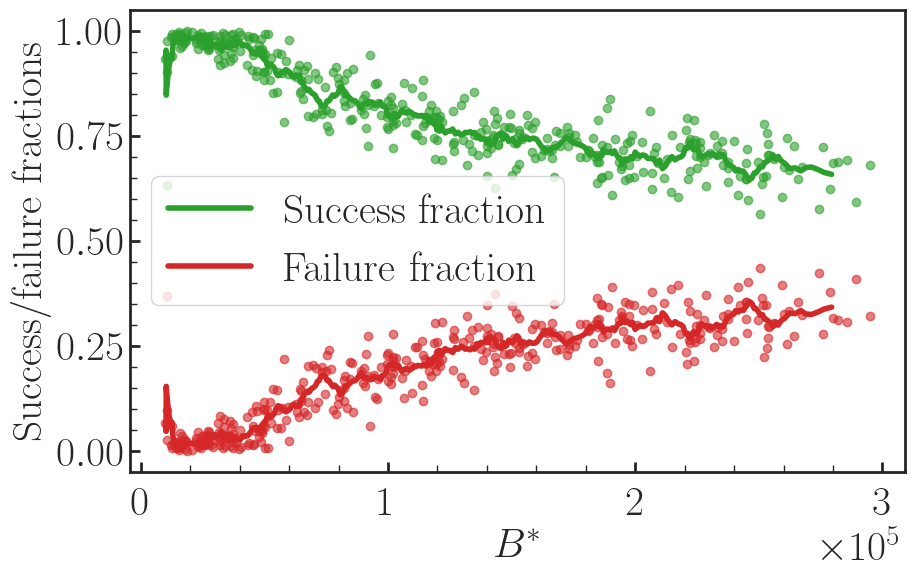

In [41]:
import numpy as np
import matplotlib.pyplot as plt

# Fix the scales for conc, time and position (adjust the units in plot titles accordingly)
t_unit = 10 # s
r_unit = 4 # mm
beta_scale = 1e+04

# Load the data from the file
folder = '/home/mukhopadhyay/Projects/maze/GNU_parallel_runs/phase_diagram/data_beta_sf/'
data = np.loadtxt(folder + 'success_fraction_combined.txt', skiprows=1)

# Extract the columns
total_exit_time = data[:, 2]
time_right = data[:, 0] / total_exit_time
time_wrong = data[:, 1] / total_exit_time
beta = np.abs(data[:, 3]) * beta_scale

# Plot Time in RIGHT path vs Beta
plt.figure(figsize=(10, 6))
plt.plot(beta, time_right, 'o', color='C2', alpha=0.6)

# Plot Time in Wrong path vs Beta
plt.plot(beta, time_wrong, 'o', color='C3', alpha=0.6)

# Plot Total exit time vs Beta
#plt.plot(beta, total_exit_time, 'o', label='Total exit time', color='green')

tr_av, tr_err = moving_average_variable_with_spread(time_right[np.argsort(beta)], n=10)
tw_av, tw_err = moving_average_variable_with_spread(time_wrong[np.argsort(beta)], n=10)
beta_av, beta_err = moving_average_variable_with_spread(beta[np.argsort(beta)], n=10)

plt.plot(beta_av, tr_av, linewidth=4, color='C2', label='Success fraction')
plt.plot(beta_av, tw_av, linewidth=4, color='C3', label='Failure fraction')
#plt.fill_between(beta_av, et_av - et_err, et_av + et_err, alpha=0.2)

# Add labels and title
plt.xlabel(r'$B^*$')
plt.ylabel(r'Success/failure fractions')
#plt.title('Times vs Beta')
#plt.axhline(306, linestyle='dashed', color='gray')
plt.ticklabel_format(axis='x', style='sci', scilimits=(0,0))
plt.legend()

# Show the plot
plt.show()


# Combined plot of ET and SF

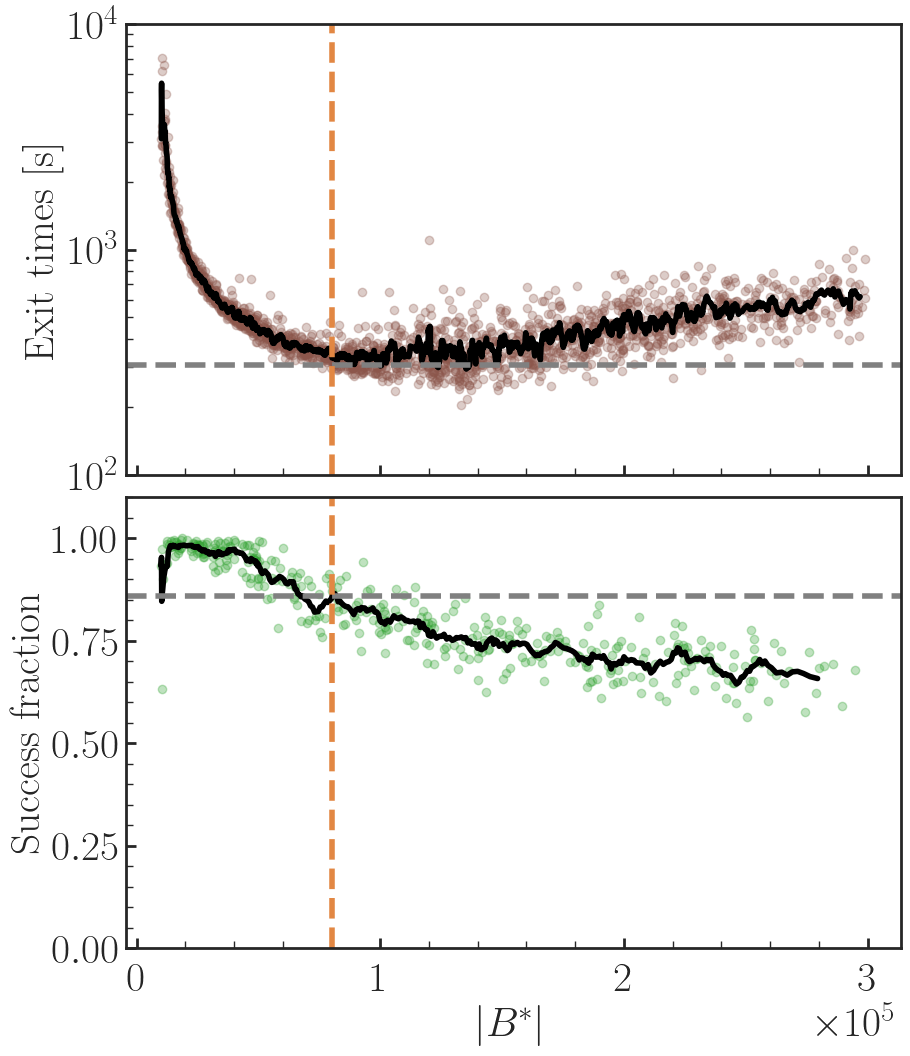

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Fix the scales for conc, time and position (adjust the units in plot titles accordingly)
t_unit = 10 # s
r_unit = 4 # mm
beta_scale = 1e+04

fig, axs = plt.subplots(2, 1, sharex=True, figsize=(10, 12))

# Remove vertical space between Axes
fig.subplots_adjust(hspace=0.05)

#######################################################

# Load data from the file
data = np.loadtxt('/home/mukhopadhyay/Projects/maze/GNU_parallel_runs/phase_diagram/data_beta_exit_times/exit_times_combined.txt', skiprows=1)

# Fix the scales for conc, time and position (adjust the units in plot titles accordingly)
t_unit = 10 # s
r_unit = 4 # mm
beta_scale = 1e+04

# Separate the columns
exit_times = data[:, 0] * t_unit
beta = np.abs(data[:, 1]) * beta_scale

# Filter out inf values
finite_indices = np.isfinite(exit_times) & np.isfinite(beta)
exit_times = exit_times[finite_indices]
beta = beta[finite_indices]


# Scatter plot of exit_times vs beta
axs[0].plot(beta, exit_times, 'o', color='C5', alpha=0.3)

et_av, et_err = moving_average_variable_with_spread(exit_times[np.argsort(beta)], n=10)
beta_av, beta_err = moving_average_variable_with_spread(beta[np.argsort(beta)], n=10)

axs[0].plot(beta_av, et_av, linewidth=4, color='k')
# Labeling the plot
#axs[0].xlabel(r'$B^*$')
axs[0].set_ylabel(r'Exit times [s]')
axs[0].axhline(306, linestyle='dashed', color='gray', linewidth=4)
axs[0].axvline(0.8*1e5, linestyle='dashed', color='#e28743', linewidth=4)
axs[0].set_yscale('log')
axs[0].set_ylim(1e2, 1e4)
#axs[0].ticklabel_format(axis='x', style='sci', scilimits=(0,0))

#######################################################


# Load the data from the file
folder = '/home/mukhopadhyay/Projects/maze/GNU_parallel_runs/phase_diagram/data_beta_sf/'
data = np.loadtxt(folder + 'success_fraction_combined.txt', skiprows=1)

# Extract the columns
total_exit_time = data[:, 2]
time_right = data[:, 0] / total_exit_time
beta = np.abs(data[:, 3]) * beta_scale

# Plot Time in RIGHT path vs Beta
axs[1].plot(beta, time_right, 'o', color='C2', alpha=0.3)

tr_av, tr_err = moving_average_variable_with_spread(time_right[np.argsort(beta)], n=10)
beta_av, beta_err = moving_average_variable_with_spread(beta[np.argsort(beta)], n=10)

axs[1].plot(beta_av, tr_av, linewidth=4, color='k', label='Success fraction')

# Add labels and title
axs[1].set_xlabel(r'$|B^*|$')
axs[1].set_ylabel(r'Success fraction')
axs[1].set_ylim(0, 1.1)
axs[1].axhline(0.86, linestyle='dashed', color='gray', linewidth=4)
axs[1].axvline(0.8*1e5, linestyle='dashed', color='#e28743', linewidth=4)
axs[1].ticklabel_format(axis='x', style='sci', scilimits=(0,0))
#axs[1].legend()

plt.show()

# Save the figure
#fig.savefig('/home/mukhopadhyay/Projects/maze/paper_figures/individual_figures/' + 'sf_and_et_vs_beta.png', dpi=300, bbox_inches='tight')